In [1]:
%matplotlib widget
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var, plot_peak_power_vs_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd
import os
import h5py 
import re
big_plt_font()
import ipywidgets as widgets
from IPython.display import display, clear_output

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

def dbm_to_nw(dbm_values):
    """Converts power from dBm to nW."""
    return (10 ** (dbm_values / 10.0)) * 1e6

In [2]:
home_dir = '/home/electron/'
data_dir = home_dir + f'artiq/experiment/artiq-master/results/2026-07-27'

In [3]:
import h5py
import pandas as pd
import numpy as np

def load_structured_h5(filepath):
    """
    Loads an ARTIQ HDF5 file saved with structured/2D arrays ('scan_data' and 't_data').
    Returns:
        df: pd.DataFrame containing driving parameters, rep_idx, and trace data.
        t_axis: np.ndarray 1D time vector.
    """
    with h5py.File(filepath, 'r') as f:
        # ARTIQ places datasets under 'datasets/'
        scan_data = f['datasets/scan_data'][:]
        
        if 'datasets/t_data' in f:
            t_axis = f['datasets/t_data'][:]
        else:
            t_axis = None
    
    # --- 1. Fix ARTIQ's (N, 1) append shape wrapper ---
    if scan_data.ndim > 1:
        scan_data = scan_data.squeeze()

    # If squeeze reduced 1 sample down to 0-D scalar, turn back to 1D
    if scan_data.ndim == 0:
        scan_data = np.array([scan_data])

    # --- 2. Convert Structured Array to Pandas DataFrame ---
    if scan_data.dtype.names is not None:
        # Extract record fields explicitly to avoid shape mismatch issues
        data_dict = {name: scan_data[name] for name in scan_data.dtype.names}
        
        # Unpack traces into a clean Python list of 1D arrays
        if 'trace' in data_dict:
            data_dict['trace'] = [np.atleast_1d(t) for t in data_dict['trace']]
            
        df = pd.DataFrame(data_dict)
    else:
        # Fallback for raw matrices (120 reps x N time points)
        rows = [{'rep_idx': idx, 'trace': trace} for idx, trace in enumerate(scan_data)]
        df = pd.DataFrame(rows)

    # --- 3. Process & Validate Time Axis ---
    if t_axis is not None:
        if t_axis.ndim > 1:
            t_axis = t_axis.squeeze()
        if t_axis.ndim > 1:  # If multi-dimensional array saved per rep
            t_axis = t_axis[0]
    else:
        # Fallback time axis generation based on trace length if missing
        trace_len = len(df['trace'].iloc[0])
        t_axis = np.arange(trace_len, dtype=np.float64)

    df['_filepath'] = filepath
    return df, t_axis

In [4]:
def compare_sweep_data(data_files, fix_ylim=False):
    """
    Interactive widget to inspect individual time traces across driving parameters
    and repetition indices using structured ARTIQ datasets with unit conversion options.
    """
    # 1. Load data into a single master DataFrame
    df_list = []
    t_axis = None
    
    for fp in data_files:
        try:
            df_single, t_axis_single = load_structured_h5(fp)
            df_list.append(df_single)
            if t_axis is None:
                t_axis = t_axis_single
        except Exception as e:
            print(f"Error loading {fp}: {e}")

    if not df_list:
        print("No valid data loaded.")
        return

    master_df = pd.concat(df_list, ignore_index=True)
    
    # Parameter columns (exclude trace, rep_idx, and metadata)
    param_cols = [c for c in master_df.columns if c not in ['trace', 'rep_idx', '_filepath']]
    print(f"Recognized parameters: {param_cols}")

    # 2. Build Widgets
    var_dropdowns = {}
    for col in param_cols:
        unique_vals = sorted(master_df[col].dropna().unique())
        var_dropdowns[col] = widgets.Dropdown(
            options=unique_vals,
            description=f'{col}:',
            style={'description_width': 'initial'}
        )

    # Unit & Y-Axis Controls
    unit_toggle = widgets.Dropdown(
        options=['dBm', 'nW'],
        value='dBm',
        description='Unit:',
        style={'description_width': 'initial'}
    )

    max_rep = int(master_df['rep_idx'].max())
    rep_slider = widgets.IntSlider(
        value=0, min=0, max=max_rep, step=1,
        description='Repetition (N):',
        continuous_update=False,
        style={'description_width': 'initial'}
    )

    btn_prev = widgets.Button(description='Prev Rep', button_style='info', icon='arrow-left')
    btn_next = widgets.Button(description='Next Rep', button_style='primary', icon='arrow-right')
    
    fix_ylim_checkbox = widgets.Checkbox(
        value=fix_ylim, description='Fix Y-Axis', indent=False
    )
    
    plot_output = widgets.Output()

    # Pre-calculate global min/max matrices for both units to make "Fix Y-Axis" snappy
    all_traces_dbm = np.vstack(master_df['trace'].values)
    all_traces_nw = dbm_to_nw(all_traces_dbm)

    # 3. Drawing Logic
    def draw_plot(change=None):
        filtered_df = master_df.copy()
        
        # Filter by parameters
        for col, dropdown in var_dropdowns.items():
            val = dropdown.value
            filtered_df = filtered_df[np.isclose(filtered_df[col], val, atol=1e-5)]
            
        # Filter by repetition index
        rep_val = rep_slider.value
        trace_row = filtered_df[filtered_df['rep_idx'] == rep_val]

        with plot_output:
            clear_output(wait=True)
            if trace_row.empty:
                print(f"No trace found for Repetition {rep_val} under selected parameters.")
                return

            y_signal = trace_row.iloc[0]['trace']
            selected_unit = unit_toggle.value

            # Convert signal if unit is nW
            if selected_unit == 'nW':
                y_signal = dbm_to_nw(y_signal)

            fig, ax = plt.subplots(figsize=(9, 4.5))
            
            # Use ms scaling if time values are large, or us if appropriate
            ax.plot(t_axis, y_signal, '.-', markerfacecolor='k', color='#1f77b4', lw=1.2)

            # Fixed Y-Limits logic dynamically adjusting to selected unit
            if fix_ylim_checkbox.value:
                target_matrix = all_traces_nw if selected_unit == 'nW' else all_traces_dbm
                g_min, g_max = np.min(target_matrix), np.max(target_matrix)
                padding = (g_max - g_min) * 0.05
                ax.set_ylim(g_min - padding, g_max + padding)

            # Title formatting fixing dropdown object output bug
            title_str = " | ".join([f"{k}: {dd.value}" for k, dd in var_dropdowns.items()])
            ax.set_title(f"{title_str} | Rep {rep_val}", fontsize=11)
            
            ax.set_xlabel("Time (s)")
            ax.set_ylabel(f"SSA Power ({selected_unit})")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


    # Navigation Handlers
    btn_prev.on_click(lambda b: setattr(rep_slider, 'value', max(rep_slider.min, rep_slider.value - 1)))
    btn_next.on_click(lambda b: setattr(rep_slider, 'value', min(rep_slider.max, rep_slider.value + 1)))

    # Register Observers
    for dd in var_dropdowns.values():
        dd.observe(draw_plot, names='value')
    unit_toggle.observe(draw_plot, names='value')
    rep_slider.observe(draw_plot, names='value')
    fix_ylim_checkbox.observe(draw_plot, names='value')

    # UI Assembly
    controls_box = widgets.VBox([
        widgets.HBox(list(var_dropdowns.values()) + [unit_toggle]),
        widgets.HBox([btn_prev, rep_slider, btn_next, fix_ylim_checkbox])
    ])
    display(widgets.VBox([controls_box, plot_output]))
    draw_plot()


In [5]:
def plot_trace_density(data_files, bins=100):
    """
    Plots a 1D probability density / histogram of signal amplitude
    for selected driving parameters across all time steps and repetitions,
    with units conversion (dBm / nW) and log-scale options.
    """
    df_list = []
    for fp in data_files:
        df_single, _ = load_structured_h5(fp)
        df_list.append(df_single)

    master_df = pd.concat(df_list, ignore_index=True)
    param_cols = [c for c in master_df.columns if c not in ['trace', 'rep_idx', '_filepath']]

    # Parameter dropdowns
    var_dropdowns = {
        col: widgets.Dropdown(options=sorted(master_df[col].dropna().unique()), description=f'{col}:')
        for col in param_cols
    }
    
    # Toggle controls
    unit_toggle = widgets.Dropdown(
        options=['dBm', 'nW'], 
        value='dBm', 
        description='Unit:', 
        style={'description_width': 'initial'}
    )
    
    log_y_cb = widgets.Checkbox(value=False, description='Log10 Y-Scale')
    density_cb = widgets.Checkbox(value=True, description='Normalize (PDF)')
    
    plot_output = widgets.Output()

    def draw_density(change=None):
        filtered_df = master_df.copy()
        for col, dropdown in var_dropdowns.items():
            filtered_df = filtered_df[np.isclose(filtered_df[col], dropdown.value, atol=1e-5)]

        with plot_output:
            clear_output(wait=True)
            if filtered_df.empty:
                print("No matching data found.")
                return

            # Flatten all data points across reps & time
            traces_matrix = np.vstack(filtered_df['trace'].values)
            signals_flat = traces_matrix.flatten()
            
            # Unit conversion if requested
            selected_unit = unit_toggle.value
            if selected_unit == 'nW':
                signals_flat = dbm_to_nw(signals_flat)

            n_reps, _ = traces_matrix.shape
            total_samples = len(signals_flat)

            fig, ax = plt.subplots(figsize=(8, 4.5))

            # 1D Histogram
            counts, bin_edges, patches = ax.hist(
                signals_flat, 
                bins=bins, 
                density=density_cb.value, 
                color='#1f77b4', 
                edgecolor='black', 
                alpha=0.7,
                log=log_y_cb.value  # Applies log10 scaling directly to histogram bins
            )

            # Compute summary statistics
            mean_val = np.mean(signals_flat)
            std_val = np.std(signals_flat)

            # Format labels according to chosen unit
            if selected_unit == 'nW':
                mean_str = f'Mean: {mean_val:.3e} nW'
                std_str = f'±1 Std: {std_val:.3e} nW'
            else:
                mean_str = f'Mean: {mean_val:.2f} dBm'
                std_str = f'±1 Std: {std_val:.2f} dB'

            # Overlay Mean & Std lines
            ax.axvline(mean_val, color='red', linestyle='--', lw=1.5, label=mean_str)
            ax.axvline(mean_val - std_val, color='orange', linestyle=':', lw=1.2, label=std_str)
            ax.axvline(mean_val + std_val, color='orange', linestyle=':', lw=1.2)

            # title_str = " | ".join([f"{k}: {dd.value}" for k, dd in var_dropdowns.items()])
            # ax.set_title(f"Amplitude Distribution ({n_reps} Reps, {total_samples:,} Points)\n{title_str}", fontsize=11)
            ax.set_xlabel(f"SSA Power ({selected_unit})")
            
            y_label = "Probability Density" if density_cb.value else "Counts"
            if log_y_cb.value:
                y_label += " (Log Scale)"
            ax.set_ylabel(y_label)

            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3, which='both' if log_y_cb.value else 'major')
            
            plt.tight_layout()
            plt.show()

    # Register callbacks
    for dd in var_dropdowns.values():
        dd.observe(draw_density, names='value')
    unit_toggle.observe(draw_density, names='value')
    log_y_cb.observe(draw_density, names='value')
    density_cb.observe(draw_density, names='value')

    # UI Assembly
    controls_box = widgets.HBox(
        list(var_dropdowns.values()) + [unit_toggle, log_y_cb, density_cb]
    )
    display(widgets.VBox([controls_box, plot_output]))
    draw_density()

In [6]:
compare_sweep_data(['/home/electron/artiq/experiment/artiq-master/results/2026-07-28/23/000010640-LoadingWithDelayedTrapDriveSwitching.h5'])

Recognized parameters: ['t_trap_drive_delay']


In [ ]:
plot_trace_density(['/home/electron/artiq/experiment/artiq-master/results/2026-07-28/23/000010640-LoadingWithDelayedTrapDriveSwitching.h5'])

In [23]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='15:50:00', stop_time='20:00:00')
plot_PvT_across_var(tip_on_files, '', var='Ex') 

Scanning datasets for Ex and calculating global y-limits...
Scan complete. Found 5 valid Ex configurations.


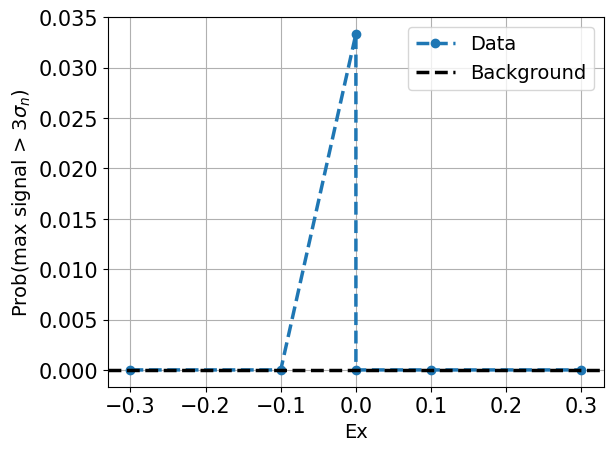

In [25]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='15:50:00', stop_time='20:00:00')

tip_off_files = [
    'data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5'
]
plot_Prob_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='Ex', xlabel='Ex', sigma_cutoff=3
                )

In [40]:
np.sqrt(dBm_to_W(4)/dBm_to_W(5))*176.31

157.13645290236067

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output
def plot_peak_timing_across_var(tip_on_files, data_dir, var='t_load', fix_xlim=False):
    """
    Plots histograms of detected power for Tip-On and Tip-Off datasets across a specified variable.

    Parameters:
    - tip_on_files: List of file paths for Tip-On datasets.
    - tip_off_files: List of file paths for Tip-Off datasets.
    - data_dir: Base directory where the data files are located.
    - var: The variable to use for mapping datasets (default is 't_load').
    - fix_xlim: Boolean (default False). If True, the x-axis limits initialize as locked 
                to the global min and max power values across all scanned datasets.
    """

    on_map = {}
    off_map = {}

    # We will track the absolute minimum and maximum power values in nW across all datasets
    global_x_min = float('inf')
    global_x_max = float('-inf')

    print(f"Scanning datasets for {var} and calculating global x-limits...")
    
    # Scan Tip-On files
    for f in tip_on_files:
        try:
            f_data = load_h5_data(f, base=data_dir)
            t_val = f_data.get(f'{var}', None)
            if t_val is not None:
                on_map[t_val] = f
                
            # Convert values to nW to find global limits
            data = f_data.get('all_meas', [])
            if len(data) > 0:
                p_nw_vals = dBm_to_W(np.concatenate(data, axis=0)) * 1e9
                global_x_min = min(global_x_min, np.min(p_nw_vals))
                global_x_max = max(global_x_max, np.max(p_nw_vals))
        except Exception as e:
            print(f"Skipping Tip-On file {f}: {e}")


    unique_t_loads = sorted(list(on_map.keys()))
    print(f"Scan complete. Found {len(unique_t_loads)} valid {var} configurations.")

    # Calculate padding for fixed limits
    has_global_limits = (global_x_min != float('inf') and global_x_max != float('-inf'))
    if has_global_limits:
        x_range = global_x_max - global_x_min
        padding = x_range * 0.05 if x_range > 0 else 1.0
        global_x_min -= padding
        global_x_max += padding
    else:
        global_x_min, global_x_max = 0, 10 # Fallbacks

    # 2. Setup UI elements (Dropdown, Buttons, Checkbox)
    t_load_dropdown = widgets.Dropdown(
        options=unique_t_loads,
        value=unique_t_loads[0] if unique_t_loads else None,
        description=f'{var}:'
    )

    btn_prev = widgets.Button(
        description='Prev',
        button_style='info',     
        icon='arrow-left'        
    )

    btn_next = widgets.Button(
        description='Next',
        button_style='primary',  
        icon='arrow-right'       
    )

    fix_xlim_checkbox = widgets.Checkbox(
        value=fix_xlim,
        description='Fix X-Axis Limits',
        disabled=not has_global_limits,
        indent=False
    )

    plot_output = widgets.Output()

    # 3. Plotting logic wrapped in an output handler
    def draw_plot(change=None):
        t_load = t_load_dropdown.value
        
        with plot_output:
            clear_output(wait=True)
            
            if t_load is None:
                print(f"No {var} configured.")
                return

            on_file_path = on_map.get(t_load)
            off_file_path = off_map.get(t_load) or (list(off_map.values())[0] if off_map else None)

            if not on_file_path:
                print(f"No Tip-On file found for {var}: {t_load}")
                return

            # Load file data
            file = load_h5_data(on_file_path, base=data_dir)
            data = file['all_meas']
            print(np.shape(data))
            
            # Calculate Power in nW for Tip-On
            t_seq_end = file['t_data']
            x_data = t_seq_end * 1e3
            t_axis = np.linspace(0, x_data, len(data[0])) 
            P_nW = np.array([t_axis[np.argmax(data_i)] for data_i in data])
            bin_size = 0.01

            # Plotting Setup
            fig, ax = plt.subplots(figsize=(7, 4))

            # 1. Plot Tip On Histogram
            counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW) - min(P_nW)) / bin_size))
            ax.bar(
                bin_edges[:-1], 
                counts / np.sum(counts), 
                width=np.diff(bin_edges),
                label='Tip on',
                align='edge', 
                alpha=0.6,
                color='blue'
            )

            # 2. Plot Tip Off Histogram (if background file exists)
            if off_file_path:
                file2 = load_h5_data(off_file_path, base=data_dir)
                data2 = file2['all_meas']
                P_nW_background = dBm_to_W(np.concatenate(data2, axis=0)) * 1e9

                counts_bg, bin_edges_bg = np.histogram(
                    P_nW_background, 
                    bins=int((max(P_nW_background) - min(P_nW_background)) / bin_size)
                )
                ax.bar(
                    bin_edges_bg[:-1], 
                    counts_bg / np.sum(counts_bg), 
                    width=np.diff(bin_edges_bg),
                    label='Tip off',
                    align='edge', 
                    alpha=0.6,
                    color='orange'
                )

            # Apply locked limits if requested
            if fix_xlim_checkbox.value:
                ax.set_xlim(global_x_min, global_x_max)

            # Graph configurations
            ax.set_yscale('log')
            ax.set_title(f"Histogram of Detected Power | {var} = {t_load}")
            ax.set_xlabel('Detected Power (nW)') 
            ax.set_ylabel('Probability Density / 0.01nW bin')
            ax.grid(True)
            ax.legend()
            plt.show()

    # 4. Define event behaviors for Slider/Buttons
    def on_dropdown_change(change):
        draw_plot(change['new'])

    def on_next_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx + 1] if idx < len(opts) - 1 else opts[0]

    def on_prev_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx - 1] if idx > 0 else opts[-1]

    # Link actions to the widgets
    t_load_dropdown.observe(on_dropdown_change, names='value')
    # Automatically redraw when the user switches fixed limits
    fix_xlim_checkbox.observe(lambda change: draw_plot(), names='value')
    
    btn_next.on_click(on_next_clicked)
    btn_prev.on_click(on_prev_clicked)

    # 5. Pack layouts and display
    controls = widgets.HBox([btn_prev, t_load_dropdown, btn_next, fix_xlim_checkbox])
    ui = widgets.VBox([controls, plot_output])

    display(ui)

    # Render the first plot
    if t_load_dropdown.value is not None:
        draw_plot(t_load_dropdown.value)